# Chicken Feature Extraction

Goal: separate individual calls and extract features that capture information about those calls and save in a csv file with 1 row per call.

Steps:
1. Import audio
2. Apply low pass filter to remove some wind noise
3. Normalize amplitude
4. Use VAD to segment into individual calls
5. Include calls of at least 50ms duration
6. Extract features and save in a df
6. Append the df rows to excel

Features extracted:
  - duration (ms)
  - time to next call (ms)
  - zero crossing rate
  - min frequency (Hz)
  - max frequency (Hz)
  - frequency with most energy (Hz)
  - frequency with most energy (Hz) in first segment, second segment, and third segment of call
  - max change in frequency of most energy across the segments of the call
  - slope of change in frequency of most energy from first third to last third segment of call (rough estimate of slope)
  - spectral centroid and bandwidth
  - MFCCs 0 - 9

Author: K Rubio

Last updated: 30Jul26

In [1]:
import librosa
import librosa.display
from vad import EnergyVAD # https://pypi.org/project/energy-vad/
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import zscore
import os
import sys
from pathlib import Path
from scipy.signal import butter, sosfiltfilt
import IPython.display as ipd
import statistics
from datetime import date

In [2]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent.parent))
print(sys.path)

['/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis/.venv/lib/python3.12/site-packages', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis']


In [3]:
from utils.time_domain_utils import (
  plot_waveform,
  rms_normalize,
  get_voice_activity_timestamps,
  get_timestamps_silences,
  split_audio_by_timestamps,
  plot_waveform_with_line,
  plot_waveform_with_labels,
)
from utils.frequency_domain_utils import (
  plot_spectrogram,
  plot_spectrogram_zoom,
  ideal_frequency_filter,
  short_time_fourier_transform,
  extract_min_max_and_most_energy_frequencies
)

## Import and visualize audio

In [4]:
filename = 'chicks_20250404_1_trills_3.wav'
filepath = f'../../data/audio/chickens/{filename}'
# Librosa.load automatically resamples at sr=22050
file, sr = librosa.load(filepath)

In [6]:
# Listen to an audio file in notebook using IPython.display
#ipd.Audio(file, rate=sr)


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Chicken'}, xlabel='Time (sec)', ylabel='Amplitude'>)

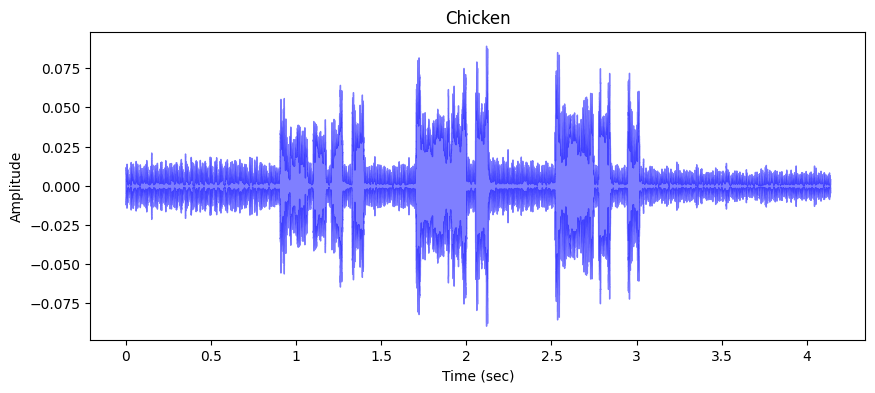

In [7]:
plot_waveform(file, 'Chicken', sr)

In [8]:
output = {}
FRAME_LENGTH = 512
HOP_LENGTH = 128
# Alternative options: FRAME_LENGTH = 1024 HOP_LENGTH = FRAME_LENGTH//4

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

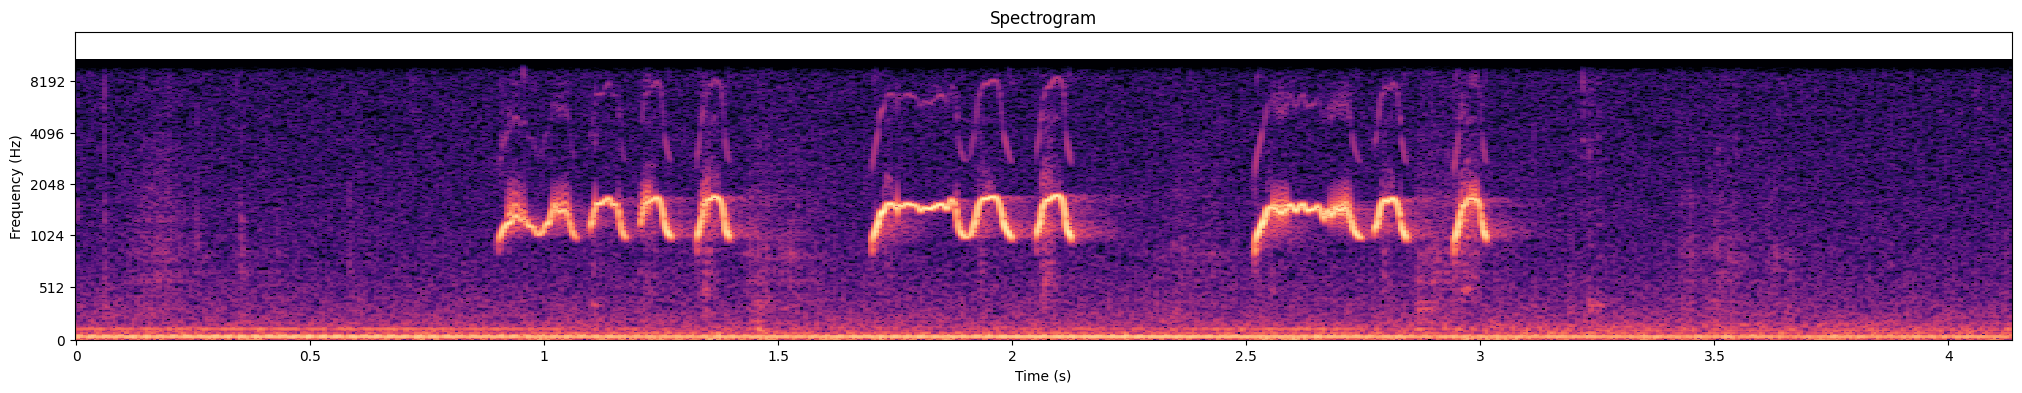

In [9]:
# Apply short-time fourier transform to change audio from time-domain to frequency-domain
stft = short_time_fourier_transform(file, FRAME_LENGTH, HOP_LENGTH)

# Plot spectrogram, use the mel scale for frequency
plot_spectrogram(stft, sr, HOP_LENGTH, "mel", 0, 16000)

## Apply high pass filter to remove some wind

In [14]:
# Apply high pass filter to remove wind sounds below 150 Hz
CUTOFF = 150 # Hz
ORDER = 4 # higher numbers means steeper cutoffs with more potential artifacts

# Butterworth high-pass filter
sos = butter(
    N=ORDER,
    Wn=CUTOFF,
    btype='highpass',
    fs=sr,
    output='sos'
)

# Apply zero-phase filtering
file_filtered = sosfiltfilt(sos, file)

stft_filtered = librosa.stft(
    file_filtered,
    n_fft=FRAME_LENGTH,
    hop_length=HOP_LENGTH
)

stft_filtered_abs = np.abs(stft_filtered) ** 2
stft_filtered_dB = librosa.power_to_db(stft_filtered_abs, ref=np.max)


# Plot spectrogram, use the mel scale for frequency
#plot_spectrogram(stft_filtered_dB, sr, HOP_LENGTH, "mel", 0, 16000)


In [17]:
# Plot waveform of filtered and normalized file
# plot_waveform(file_filtered, 'Chicken')

## Normalize amplitude

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Chicken'}, xlabel='Time (sec)', ylabel='Amplitude'>)

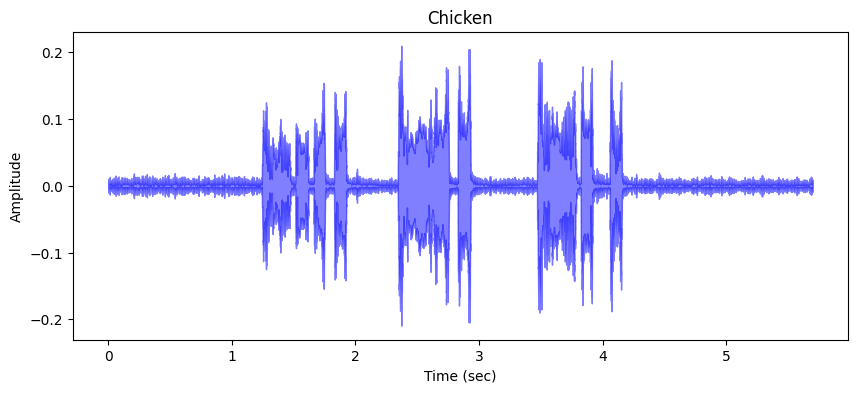

In [18]:
# Normalize audio signal so amplitude/volume is consistent across files using root mean square energy
file_normalized = rms_normalize(file_filtered, target_dBFS=-30.0)

# Plot waveform
plot_waveform(file_normalized, 'Chicken')

In [19]:
# Convert back to frequency domain for later use
stft_normalized = librosa.stft(
    file_normalized,
    n_fft=FRAME_LENGTH,
    hop_length=HOP_LENGTH
)

stft_normalized_abs = np.abs(stft_normalized) ** 2
stft_normalized_dB = librosa.power_to_db(stft_normalized_abs, ref=np.max)

## Use VAD to segment into individual calls

In [20]:
# VAD Settings --> adjust these depending on how fast the chicken is making sounds
ENERGY_THRESHOLD = .01
VAD_FRAME_LENGTH = 5 # milliseconds
VAD_FRAME_SHIFT = 2 # milliseconds
# Generally a silence longer than 25ms is should separate call from another
MIN_ICI = 25 # in milliseconds


In [21]:
# VAD
vad = EnergyVAD(
    frame_length=VAD_FRAME_LENGTH,
    frame_shift=VAD_FRAME_SHIFT,
    sample_rate=sr,
    energy_threshold=ENERGY_THRESHOLD)
vad_output = vad(file_normalized)
# Get timestamps for calls
calls = get_voice_activity_timestamps(vad_output=vad_output, frame_shift=VAD_FRAME_SHIFT, min_silence_duration=MIN_ICI)

if len(calls) < 4:
    print('Error! This is not enough calls. Try increasing the ENERGY_THRESHOLD')

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Chicken calls'}, xlabel='Time (sec)', ylabel='Amplitude'>)

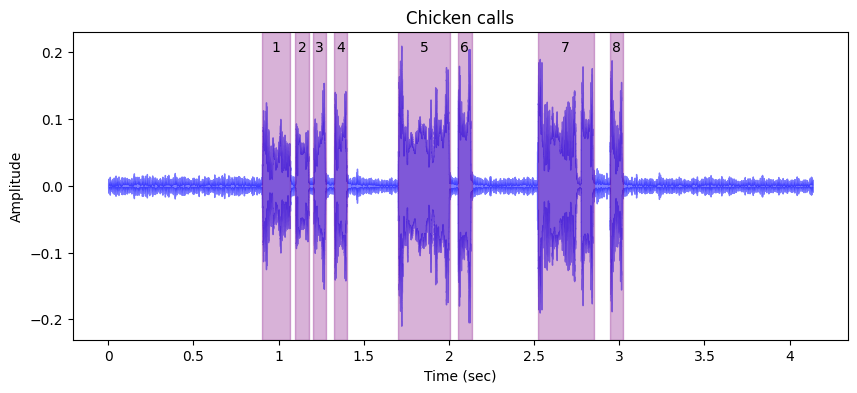

In [22]:
plot_waveform(file_normalized, 'Chicken calls', sr, calls)

In [ ]:
# Cut out calls less than the minimum duration
# Most chicken clucks are at least 25 ms, although nestbox ticking ticking sounds are briefer
MIN_CALL_DURATION = 0.025 # 25 ms

longer_calls = []
for i, call in enumerate(calls):
  if call['end'] - call['start'] > MIN_CALL_DURATION:
    longer_calls.append(calls[i])

calls = longer_calls
#plot_waveform_with_labels(file_normalized, 'Chicken calls', sr, calls, [], True)

In [26]:
## OPTIONAL - Remove some of the sections if they don't represent actual calls
calls_to_remove = []
calls_to_remove.sort(reverse = True)

for call_to_remove in calls_to_remove:
  calls.pop(call_to_remove)

#plot_waveform_with_labels(file_normalized, 'Chicken calls', sr, calls, [], True)


## Time Domain Feature Extraction

In [27]:
# Extract time data
filenames = []
starts = []
ends = []
durations_ms = []
for call in calls:
    filenames.append(filename)
    starts.append(call['start'])
    ends.append(call['end'])
    durations_ms.append((call['end'] - call['start']) * 1000)

start_end_data = {'filename': filenames, 'start': starts, 'end': ends, 'duration_ms': durations_ms}
df = pd.DataFrame(start_end_data)

#df


In [28]:
# Add call_num as second column
df.insert(1, "call_num", range(1, len(df)+1 ))
#df


In [29]:
# Add time_to_next_call_ms to the dataframe
df["time_to_next_call_ms"] = ((df["start"].shift(-1) - df["end"]) * 1000).clip(lower=0)
#df

## Frequency Domain Feature Extraction

In [31]:
frequencies = librosa.fft_frequencies(sr=sr, n_fft=FRAME_LENGTH)

# Frequency domain data
times = librosa.frames_to_time(np.arange(stft_normalized_abs.shape[1]), sr=sr, hop_length=HOP_LENGTH)

In [32]:
ENERGY_CUTOFF = 0.04

In [33]:
frequency_data = []
for i, row in df.iterrows():
    call_data = extract_min_max_and_most_energy_frequencies(
        stft_normalized_abs,
        times,
        row['start'],
        row['end'],
        ENERGY_CUTOFF,
        frequencies)
    frequency_data.append(call_data)

# Add these as columns to the data frame
min_freqs = []
max_freqs = []
max_energy_freqs = []
for row in frequency_data:
    min_freqs.append(row['min_freq'])
    max_freqs.append(row['max_freq'])
    max_energy_freqs.append(row['max_energy_freq'])
df['min_freq'] = min_freqs
df['max_freq'] = max_freqs  
df['max_energy_freq'] = max_energy_freqs
#df

In [34]:
# Divide each call into 3 pieces by timestamps, then get frequency of most energy for first, second and third part
# also calculate the differences between the highest peak freq in a third of the call and the lowest, as well as overall slope estimate
for i, row in df.iterrows():
  # divide each call into 3 segments (one-third)
  duration_s = row['duration_ms']/1000 # convert to seconds
  seg_duration = round(duration_s / 3, 3) # cut into thirds
  seg1_start = round(row['start'], 3)
  seg1_end = round(row['start'] + seg_duration, 3)
  seg2_start = seg1_end
  seg2_end = round(seg2_start + seg_duration, 3)
  seg3_start = seg2_end
  seg3_end = row['end']

  seg1_data = extract_min_max_and_most_energy_frequencies(
    stft_normalized_abs,
    times,
    seg1_start,
    seg1_end,
    ENERGY_CUTOFF,
    frequencies)

  seg2_data = extract_min_max_and_most_energy_frequencies(
    stft_normalized_abs,
    times,
    seg2_start,
    seg2_end,
    ENERGY_CUTOFF,
    frequencies)

  seg3_data = extract_min_max_and_most_energy_frequencies(
    stft_normalized_abs,
    times,
    seg3_start,
    seg3_end,
    ENERGY_CUTOFF,
    frequencies)

  seg1_max_freq = seg1_data['max_energy_freq']
  seg2_max_freq = seg2_data['max_energy_freq']
  seg3_max_freq = seg3_data['max_energy_freq']

  # subtract highest of the 3 freq measures from the lowest one to estimate overall change in freq over the call
  freq_change = np.ptp([
    seg1_max_freq,
    seg2_max_freq,
    seg3_max_freq
])
  
  # subtract peak energy at end from peak energy at beginning and divide by duration to estimate overall slope
  slope = (seg3_max_freq - seg1_max_freq) / duration_s
  
  # add values to the df
  df.at[i, "seg1_max_energy_freq"] = seg1_max_freq
  df.at[i, "seg2_max_energy_freq"] = seg2_max_freq
  df.at[i, "seg3_max_energy_freq"] = seg3_max_freq
  df.at[i, "freq_change"] = freq_change
  df.at[i, "slope"] = slope
#df

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

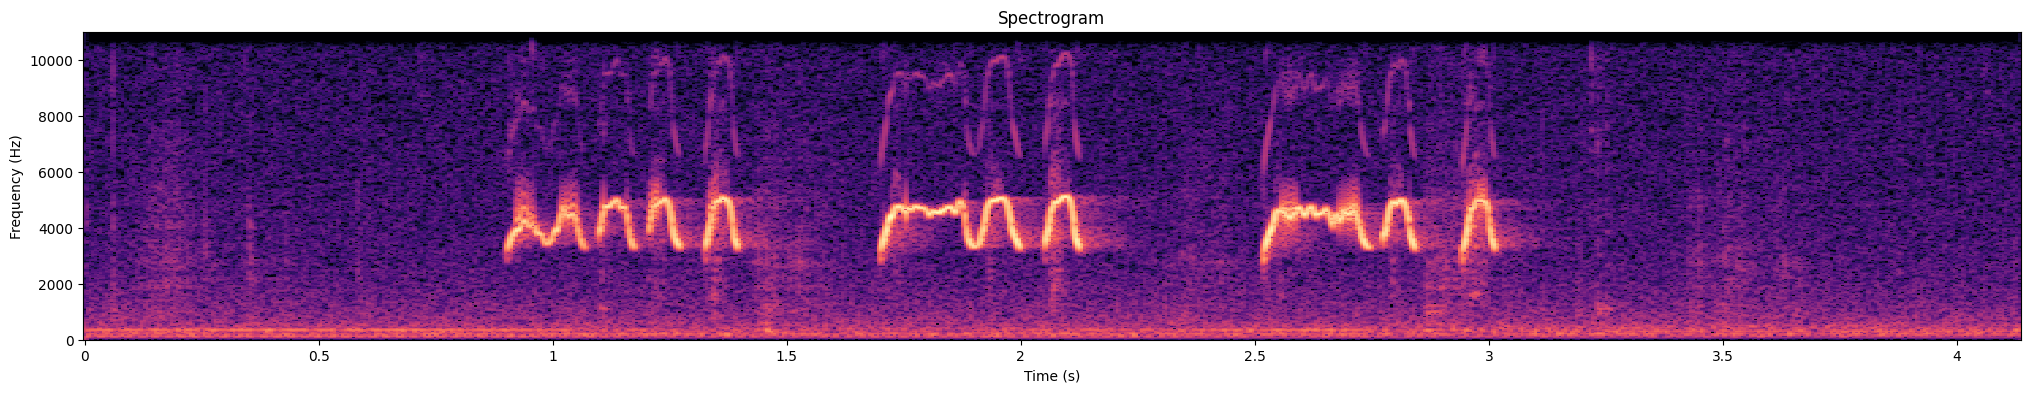

In [40]:
# Zoom into the spectrogram to check it using linear scale for frequency
plot_spectrogram(stft_normalized_dB, sr, HOP_LENGTH, "linear", 0, sr / 2)

## Extract ZCR

In [41]:
call_audios = split_audio_by_timestamps(file_normalized, calls, sr)
len(call_audios)

8

In [42]:
# Listen to an audio file in notebook using IPython.display
#ipd.Audio(call_audios[0], rate=sr)

[np.float64(0.34698275862068967), np.float64(0.37388392857142855), np.float64(0.3590745192307692), np.float64(0.3588169642857143), np.float64(0.390625), np.float64(0.3653645833333333), np.float64(0.3744860197368421), np.float64(0.3529575892857143)]


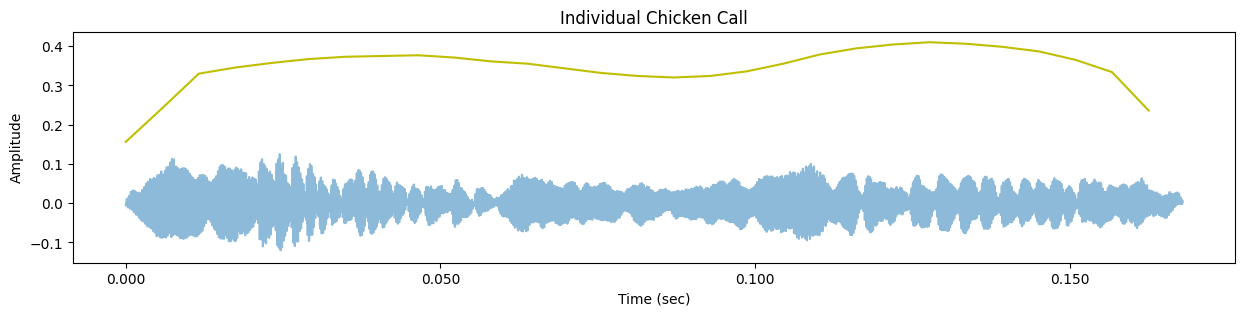

In [48]:
# Calculate ZCR using librosa.feature.zero_crossing_rate
zcrs = []
zcr_avgs = []
for call in call_audios:
  zcr = librosa.feature.zero_crossing_rate(y=call, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
  zcrs.append(zcr)
  zcr_avgs.append(statistics.mean(zcr))
print(zcr_avgs)
plot_waveform_with_line(call_audios[0], "Individual Chicken Call", HOP_LENGTH, sr, zcrs[0], "y")

In [44]:
df['zcr'] = zcr_avgs
#df

## Extract MFCCs

In [45]:
# extract MFCCs 0-9 for each call, average for each call and save in df
for i, row in df.iterrows():
    mfccs = librosa.feature.mfcc(y=call_audios[i], sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH, n_mfcc=10)
    for j in range(mfccs.shape[0]):
        df.at[i, f"mfcc{j}_avg"] = np.mean(mfccs[j])
        df.at[i, f"mfcc{j}_std"] = np.std(mfccs[j])
        df.at[i, f"mfcc{j}_min"] = np.min(mfccs[j])
        df.at[i, f"mfcc{j}_max"] = np.max(mfccs[j])
#df

## Extract Spectral centroid and bandwidth

In [46]:
# Extract and find average for spectral centroid and bandwidth for each call and save in df
for i, row in df.iterrows():
    sc = librosa.feature.spectral_centroid(y=call_audios[i], sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    sban = librosa.feature.spectral_bandwidth(y=call_audios[i], sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    df.at[i, "spectral_centroid"] = np.mean(sc)
    df.at[i, "spectral_bandwidth"] = np.mean(sban)
#df

## Add metadata and export to csv

In [47]:
df["sample_rate"] = sr
df["frame_length"] = FRAME_LENGTH
df["vad_energy_threshold_used"] = ENERGY_THRESHOLD
#df

In [555]:
# Export results to csv
df.to_csv(f"../../data/output/chickens/{date.today()}_output.csv", mode="a", header=False, index=False)
